# Hotel Booking Cancellation Prediction

## Introduction / Problem Overview

Hotel booking cancellations create important challenges for hotel management because they affect **occupancy planning, staffing, revenue stability, and overbooking decisions**. When many reservations are canceled, hotels may lose revenue and face difficulty using rooms efficiently.

This project applies supervised machine learning classification methods to predict whether a booking will be canceled. The goal is to compare different models, evaluate their performance, and identify the algorithm that best supports practical business decision-making.


## Dataset Description

This project uses the **Hotel Booking Demand** dataset, which contains hotel reservation records for **City Hotel** and **Resort Hotel** bookings. Each row represents one booking, and the target variable, `is_canceled`, indicates whether the reservation was canceled (`1`) or not (`0`).

The dataset includes a mixture of customer, reservation, and service-related information such as:
- booking lead time
- meal type
- market segment
- distribution channel
- average daily rate (ADR)
- number of special requests
- customer type
- room assignment details

This dataset is suitable for a **binary classification** task because the main objective is to predict a yes/no outcome from multiple features.


## Project Objective

The objective of this project is to build and compare several supervised machine learning classification models to predict whether a hotel booking will be canceled.

More specifically, this analysis aims to:
- preprocess and clean the booking data
- explore variables related to cancellation behavior
- train and evaluate multiple classification models
- compare results using appropriate evaluation metrics
- select the model that best satisfies the project goal

The final outcome is a model and interpretation that can help hotels better understand cancellation patterns and support decisions that reduce revenue loss.


## Data Cleaning and Preprocessing

Before modeling, the dataset was cleaned and prepared carefully:
- duplicate rows were removed
- columns with strong leakage or too many missing values were dropped
- missing values in selected columns were filled using suitable methods
- categorical variables were encoded
- numerical features were scaled when needed for specific models

These preprocessing steps improved the quality of the dataset and made the model comparison more reliable.


## Code Documentation Notes

The code cells below include inline comments using `#` so each step of the workflow is easy to follow.  
These comments explain the purpose of the code for data cleaning, exploratory data analysis, preprocessing, modeling, evaluation, and final comparison.


In [ ]:
# Import the main libraries for data analysis, visualization, and machine learning.
import pandas as pd
import numpy as np
import sklearn.ensemble
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the hotel booking dataset and preview the first rows.
data = pd.read_csv('hotel_bookings.csv')
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
# Check the number of rows and columns in the original dataset.
print('Dataset size is :', data.shape)

Dataset size is : (119390, 32)


In [ ]:
# Inspect column names, data types, and missing values.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
# Explore the distribution of countries in the dataset.
data['country'].value_counts()

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
       ...  
DJI        1
BWA        1
HND        1
VGB        1
NAM        1
Name: count, Length: 177, dtype: int64

In [ ]:
# Check how many bookings are linked to each travel agent.
data['agent'].value_counts()

agent
9.0      31961
240.0    13922
1.0       7191
14.0      3640
7.0       3539
         ...  
289.0        1
432.0        1
265.0        1
93.0         1
304.0        1
Name: count, Length: 333, dtype: int64

In [ ]:
# Count the number of unique values in each column.
data.nunique()

hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
assigned_room_type                  12
booking_changes                     21
deposit_type                         3
agent                              333
company                            352
days_in_waiting_list     

In [ ]:
# View the frequency of each hotel type.
data['hotel'].value_counts()

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

In [ ]:
# Check whether the 'babies' column contains unusual values.
data['babies'].value_counts()

babies
0     118473
1        900
2         15
10         1
9          1
Name: count, dtype: int64

In [ ]:
# Inspect the 'company' column before deciding whether to keep or drop it.
data['company'].value_counts()

company
40.0     927
223.0    784
67.0     267
45.0     250
153.0    215
        ... 
104.0      1
531.0      1
160.0      1
413.0      1
386.0      1
Name: count, Length: 352, dtype: int64

In [ ]:
# View the number of bookings in each market segment.
data['market_segment'].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [ ]:
# View the number of bookings in each distribution channel.
data['distribution_channel'].value_counts()

distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

In [ ]:
# Count duplicate rows in the dataset.
data.duplicated().sum()

np.int64(31994)

In [ ]:
# Remove duplicate rows to avoid repeated observations in the analysis.
data.drop_duplicates(inplace=True)

In [ ]:
# Confirm the new dataset shape after removing duplicates.
data.shape

(87396, 32)

In [ ]:
# Recheck the dataset structure after removing duplicates.
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87396 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87392 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            8739

In [ ]:
# Drop columns with too many missing values or leakage from the future target.
#Dropping company and agent just for missing values and 'reservation_status' and 'reservation_status_date' for cuse of leakage in modelling.
data.drop(columns=['company', 'agent', 'reservation_status', 'reservation_status_date'], inplace=True)

In [ ]:
# Confirm the new dataset shape after dropping columns.
data.shape

(87396, 28)

In [ ]:
# Fill missing values in 'children' with the most frequent value (mode).
data['children'].fillna(data['children'].mode()[0], inplace=True)
data['children'].shape

C:\Users\persh\AppData\Local\Temp\ipykernel_16684\104712648.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['children'].fillna(data['children'].mode()[0], inplace=True)


(87396,)

In [ ]:
# Fill missing values in 'country' with the most frequent country.
data['country'] = data['country'].fillna(data['country'].mode()[0])
data['country'].shape

(87396,)

In [ ]:
# Verify that missing values have been handled correctly.
data.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

## Exploratory Data Analysis

Before training the models, exploratory data analysis was performed to understand how booking features relate to cancellation behavior. The following charts and pairplots highlight patterns that may be useful for classification, such as lead time, deposit type, market segment, customer behavior, and service requests.


In [ ]:
# Check the class balance of the target variable.
data['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.725102
1    0.274898
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Cancellation Rate by Hotel Type')

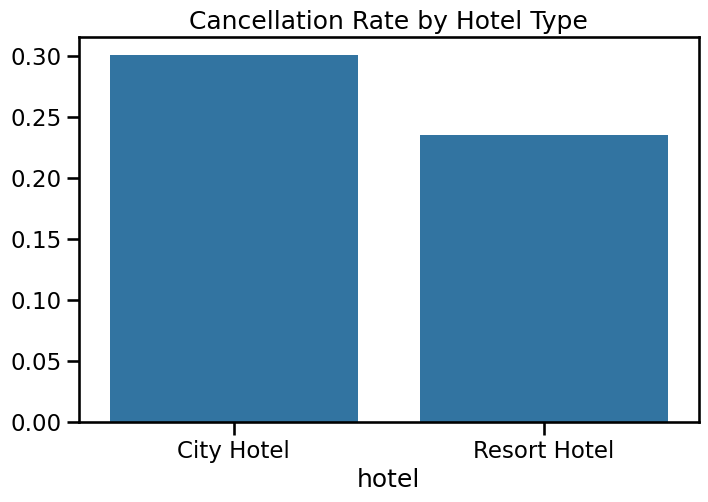

In [ ]:
# Calculate and visualize cancellation rate by hotel type.
cancel_rate_by_hotel = data.groupby('hotel')['is_canceled'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=cancel_rate_by_hotel.index, y=cancel_rate_by_hotel.values)
plt.title('Cancellation Rate by Hotel Type')

Text(0.5, 1.0, 'Cancellation Rate by Deposit Type')

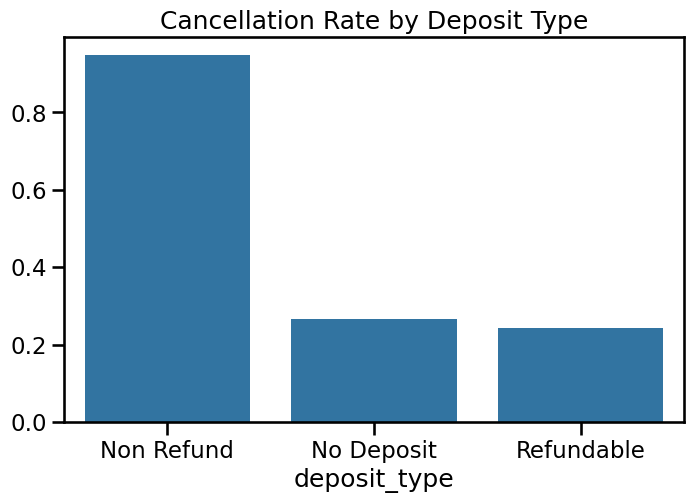

In [ ]:
# Calculate and visualize cancellation rate by deposit type.
cancel_rate_by_deposit_type = data.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=cancel_rate_by_deposit_type.index, y=cancel_rate_by_deposit_type.values)
plt.title('Cancellation Rate by Deposit Type')


C:\Users\persh\AppData\Local\Temp\ipykernel_16684\3980639845.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancel_rate_by_market_segment.index, y=cancel_rate_by_market_segment.values, palette='viridis')


Text(0.5, 1.0, 'Cancellation Rate by Market Segment')

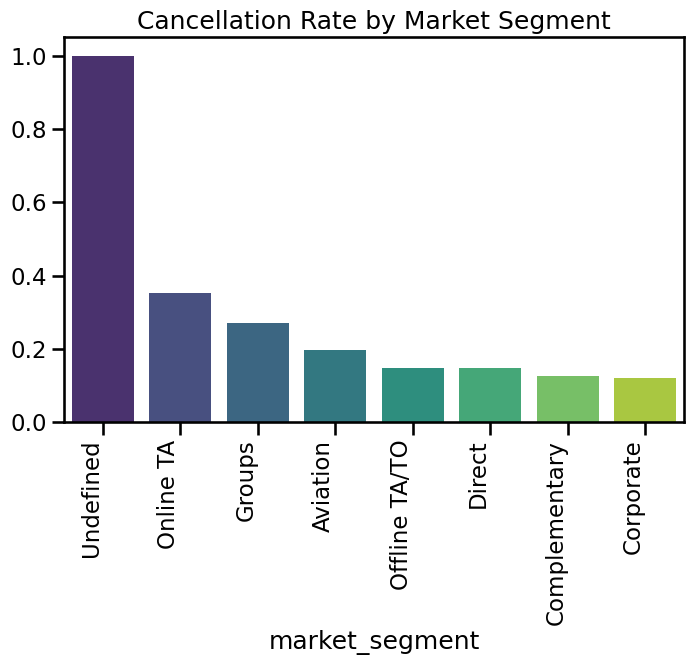

In [ ]:
# Calculate and visualize cancellation rate by market segment.
cancel_rate_by_market_segment = data.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=cancel_rate_by_market_segment.index, y=cancel_rate_by_market_segment.values, palette='viridis')
plt.xticks(rotation=90, ha='right')
plt.title('Cancellation Rate by Market Segment')

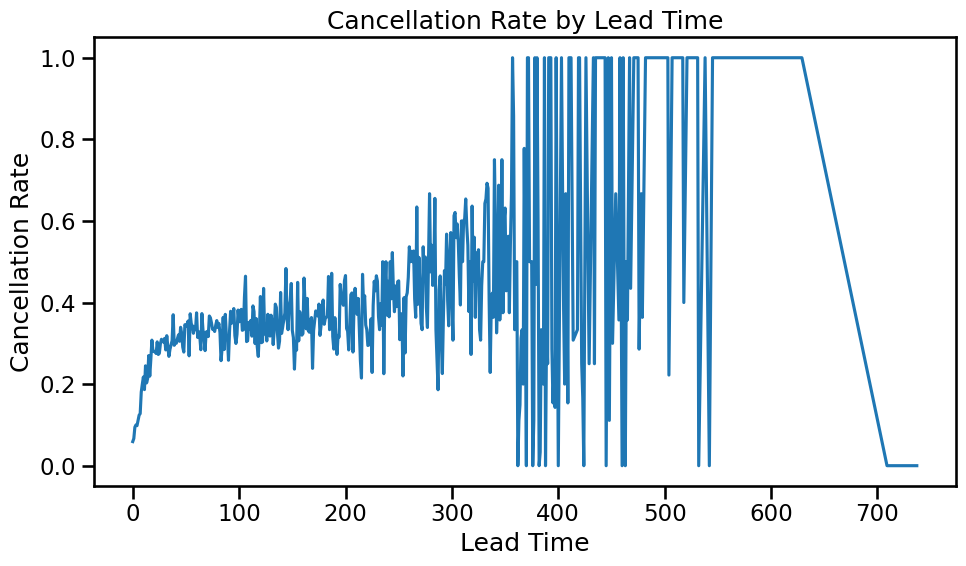

In [ ]:
# Visualize how cancellation rate changes with lead time.
cancel_rate_by_lead_time = data.groupby('lead_time')['is_canceled'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.lineplot(data=cancel_rate_by_lead_time.reset_index(), x='lead_time', y='is_canceled')
plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time')
plt.ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()

C:\Users\persh\AppData\Local\Temp\ipykernel_16684\228026964.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancel_rate_by_customer_type.index, y=cancel_rate_by_customer_type.values, palette='viridis')


Text(0.5, 1.0, 'Cancellation Rate by Customer Type')

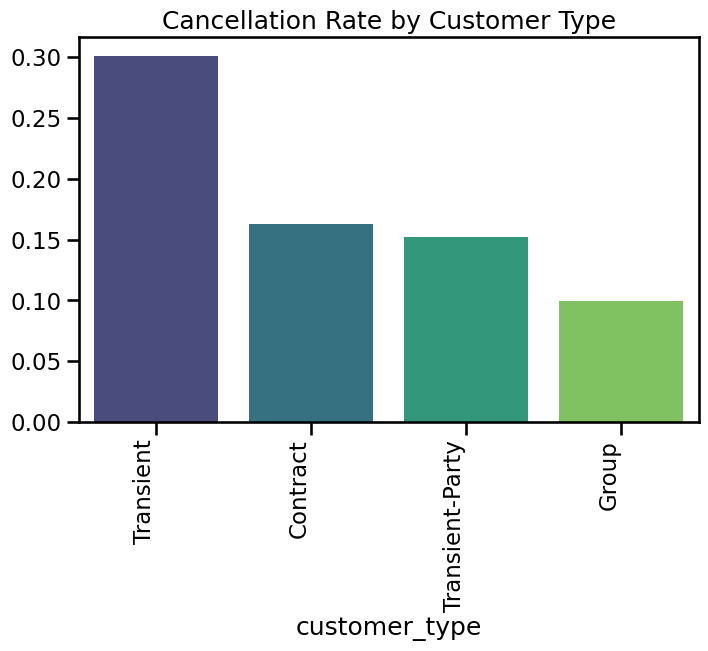

In [ ]:
# Calculate and visualize cancellation rate by customer type.
cancel_rate_by_customer_type = data.groupby('customer_type')['is_canceled'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=cancel_rate_by_customer_type.index, y=cancel_rate_by_customer_type.values, palette='viridis')
plt.xticks(rotation=90, ha='right')
plt.title('Cancellation Rate by Customer Type')

In [ ]:
# Display all column names to review available features.
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='object')

In [ ]:
# Import preprocessing tools for scaling and encoding.
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler

In [ ]:
# Take a random sample for faster pairplot visualization.
sample_data = data.sample(5000, random_state=42)

**Quick interpretation:**  
This pairplot compares `lead_time` and `adr` across canceled and non-canceled bookings. It helps check whether canceled bookings tend to cluster around longer lead times or different price levels.


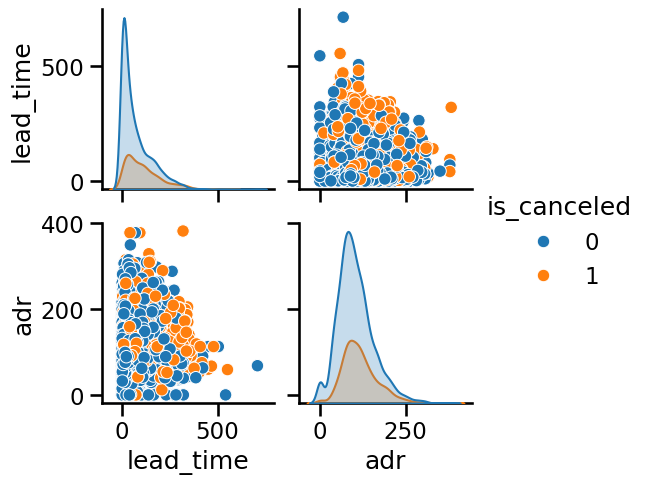

In [ ]:
# Create a pairplot to study the relationship between lead time, ADR, and cancellation status.
plot_data_1 = sample_data[['lead_time', 'adr', 'is_canceled']].copy()

g = sns.pairplot(plot_data_1, hue='is_canceled', corner=True, diag_kind='hist')

for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(axis='x', labelrotation=35)
        ax.tick_params(axis='y', labelrotation=0)
        ax.set_xlabel(ax.get_xlabel(), fontsize=9)
        ax.set_ylabel(ax.get_ylabel(), fontsize=9)

g.fig.subplots_adjust(top=0.92, wspace=0.15, hspace=0.15)
g.fig.suptitle('Pairplot of Lead Time and ADR by Cancellation Status', fontsize=13)

plt.show()

In [ ]:
# Convert selected categorical variables into dummy variables for modeling.
categorical_cols = [
    'hotel',
    'meal',
    'market_segment',
    'distribution_channel',
    'deposit_type',
    'customer_type',
    'reserved_room_type',
    'assigned_room_type',
    'arrival_date_month',
    'country'
]

data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [ ]:
# Check the dataset shape after one-hot encoding.
data.shape

(87396, 246)

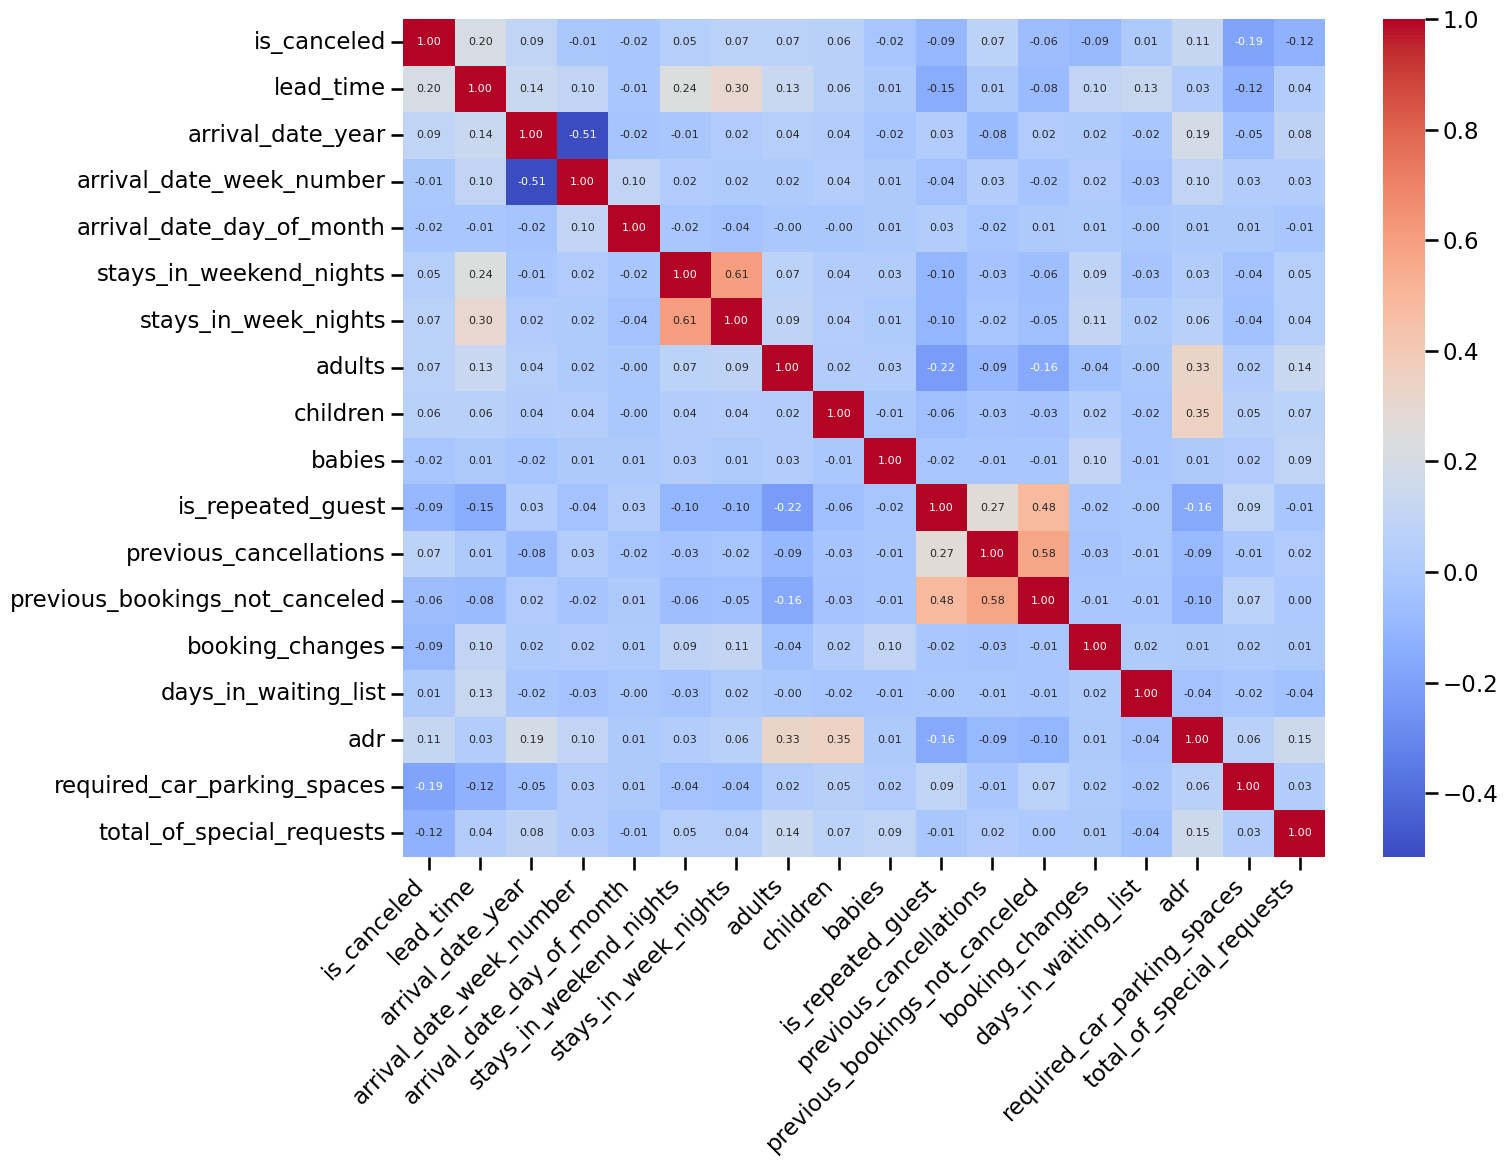

In [ ]:
# Plot a correlation heatmap for the numeric variables in the sample.
plt.figure(figsize=(16,12))
corr = sample_data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', annot_kws={'size':8})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

([0, 1], [Text(0, 0, '0'), Text(1, 0, '1')])

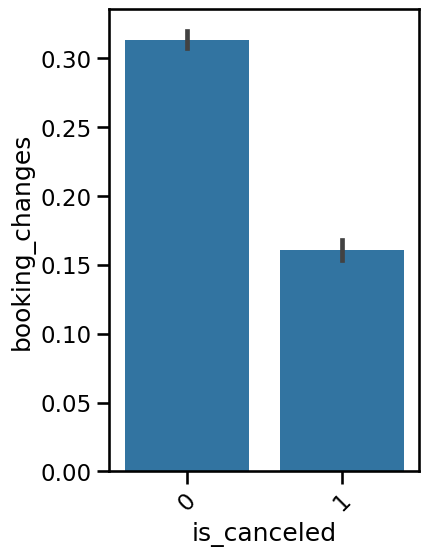

In [ ]:
# Compare average booking changes for canceled vs. non-canceled bookings.
plt.figure(figsize=(4,6))
sns.barplot(x = 'is_canceled', y='booking_changes', data=data)
plt.xticks(rotation=45)

([0, 1], [Text(0, 0, '0'), Text(1, 0, '1')])

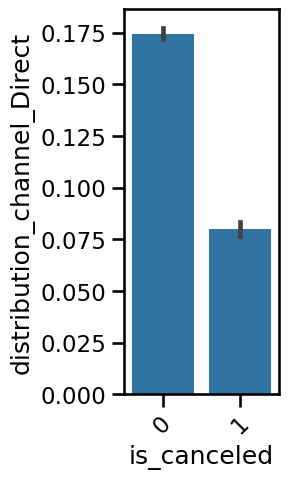

In [ ]:
# Check whether direct distribution channel is related to cancellation status.
plt.figure(figsize=(2,5))
sns.barplot(x = 'is_canceled', y='distribution_channel_Direct', data=data)
plt.xticks(rotation=45)

In [ ]:
# Display summary statistics for the cleaned dataset.
data.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,87396.0,0.274898,0.446466,0.00,0.0,0.0,1.0,1.0
lead_time,87396.0,79.891368,86.052325,0.00,11.0,49.0,125.0,737.0
arrival_date_year,87396.0,2016.210296,0.686102,2015.00,2016.0,2016.0,2017.0,2017.0
arrival_date_week_number,87396.0,26.838334,13.674572,1.00,16.0,27.0,37.0,53.0
arrival_date_day_of_month,87396.0,15.815541,8.835146,1.00,8.0,16.0,23.0,31.0
stays_in_weekend_nights,87396.0,1.005263,1.031921,0.00,0.0,1.0,2.0,19.0
stays_in_week_nights,87396.0,2.625395,2.053584,0.00,1.0,2.0,4.0,50.0
adults,87396.0,1.875795,0.626500,0.00,2.0,2.0,2.0,55.0
children,87396.0,0.138633,0.455871,0.00,0.0,0.0,0.0,10.0
babies,87396.0,0.010824,0.113597,0.00,0.0,0.0,0.0,10.0


In [ ]:
# Detect outliers in 'lead_time' using the IQR method.
Q1= data['lead_time'].quantile(0.25)
Q3= data['lead_time'].quantile(0.75)
IQR= Q3 - Q1
lower_band = Q1- 1.5 * IQR
upper_band = Q3 + 1.5 * IQR

outliers = data[(data['lead_time'] < lower_band) | (data['lead_time'] > upper_band) ]
print(outliers)

        is_canceled  lead_time  arrival_date_year  arrival_date_week_number  \
0                 0        342               2015                        27   
1                 0        737               2015                        27   
81                1        368               2015                        27   
82                0        364               2015                        27   
85                0        324               2015                        27   
...             ...        ...                ...                       ...   
119148            0        457               2017                        34   
119228            0        341               2017                        35   
119296            0        303               2017                        35   
119297            0        332               2017                        35   
119334            0        325               2017                        35   

        arrival_date_day_of_month  stays_in_weekend

<Axes: xlabel='lead_time'>

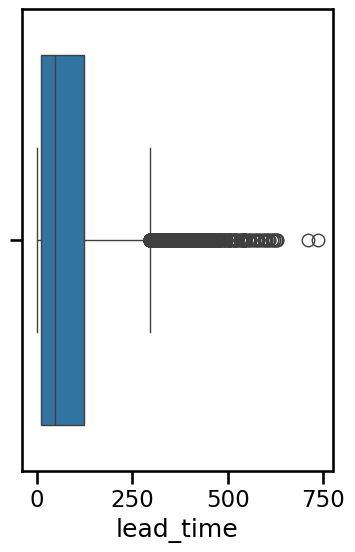

In [ ]:
# Visualize the distribution and outliers of lead time with a boxplot.
plt.figure(figsize=(4,6))
sns.boxplot(x=data['lead_time'])

In [ ]:
# Define a helper function to compute the main classification metrics.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

def get_metrics(y_test, y_pred, y_pred_proba=None):
    results = {}
    results['accuracy'] = accuracy_score(y_test, y_pred)
    results['precision'] = precision_score(y_test, y_pred)
    results['recall'] = recall_score(y_test, y_pred)
    results['f1_score'] = f1_score(y_test, y_pred)

    if y_pred_proba is not None:
        results['roc_auc'] = roc_auc_score(y_test, y_pred_proba)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return results

In [ ]:
# Define helper functions to extract and visualize model coefficients.
# Extract and sort feature coefficients
def get_feature_coefs(regression_model, label_index, columns):
    coef_dict = {}
    for coef, feat in zip(regression_model.coef_[label_index, :], columns):
        if abs(coef) >= 0.01:
            coef_dict[feat] = coef
    # Sort coefficients
    coef_dict = {k: v for k, v in sorted(coef_dict.items(), key=lambda item: item[1])}
    return coef_dict

# Generate bar colors based on if value is negative or positive
def get_bar_colors(values):
    color_vals = []
    for val in values:
        if val <= 0:
            color_vals.append('r')
        else:
            color_vals.append('g')
    return color_vals

# Visualize coefficients
def visualize_coefs(coef_dict):
    features = list(coef_dict.keys())
    values = list(coef_dict.values())
    y_pos = np.arange(len(features))
    color_vals = get_bar_colors(values)
    plt.rcdefaults()
    fig, ax = plt.subplots()
    ax.barh(y_pos, values, align='center', color=color_vals)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    # labels read top-to-bottom
    ax.invert_yaxis()
    ax.set_xlabel('Feature Coefficients')
    ax.set_title('')
    plt.show()

In [ ]:
# Separate features (X) from the target variable (y).
X = data.loc[: , data.columns!='is_canceled']
y=data.loc[:, 'is_canceled']

In [ ]:
# Split the dataset into training and testing sets using stratification.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Standardize the features for models that are sensitive to scale.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression


In [ ]:
# Train the Logistic Regression model on the scaled training data.
from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression(max_iter=1000, random_state=42)
LR_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
# Make predictions and evaluate Logistic Regression.
y_pred = LR_model.predict(X_test_scaled)
y_pred_proba = LR_model.predict_proba(X_test_scaled)[:, 1]

scores_LR = get_metrics(y_test, y_pred, y_pred_proba)
print(scores_LR)

Confusion Matrix:
[[11558  1117]
 [ 2482  2323]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.87     12675
           1       0.68      0.48      0.56      4805

    accuracy                           0.79     17480
   macro avg       0.75      0.70      0.71     17480
weighted avg       0.78      0.79      0.78     17480

{'accuracy': 0.7941075514874142, 'precision': 0.6752906976744186, 'recall': 0.48345473465140476, 'f1_score': 0.5634930260764099, 'roc_auc': 0.8437922446826633}


C:\Users\persh\AppData\Local\Temp\ipykernel_16684\2439316481.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(scores_LR, palette= 'pastel')


<Axes: >

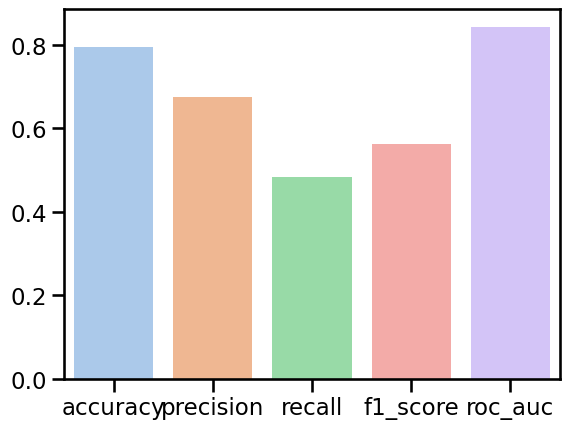

In [ ]:
# Plot the main performance metrics for Logistic Regression.
plt.figure(figsize=(8, 4))
sns.barplot(x=list(scores_LR.keys()), y=list(scores_LR.values()), hue=list(scores_LR.keys()), legend=False, palette='pastel')
plt.title('Logistic Regression Performance Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


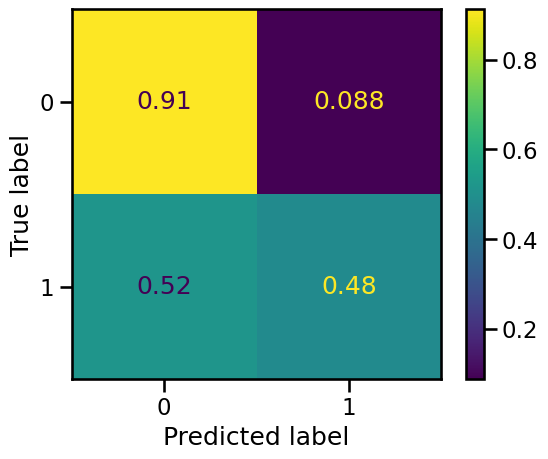

In [ ]:
# Plot the normalized confusion matrix for Logistic Regression.
from sklearn.metrics import ConfusionMatrixDisplay
cf = confusion_matrix(y_test, y_pred, normalize='true')


sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=LR_model.classes_)
disp.plot()
plt.show()

In [ ]:
# Review the encoded feature names before coefficient interpretation.
data.columns.T

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies',
       ...
       'country_UMI', 'country_URY', 'country_USA', 'country_UZB',
       'country_VEN', 'country_VGB', 'country_VNM', 'country_ZAF',
       'country_ZMB', 'country_ZWE'],
      dtype='object', length=246)

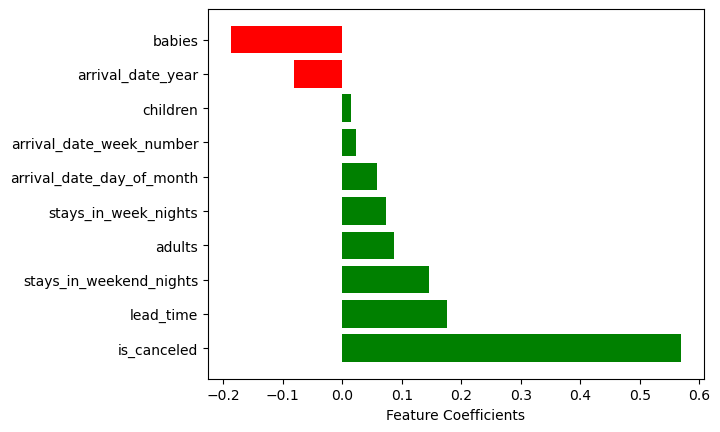

In [ ]:
# Visualize selected Logistic Regression coefficients.
coef_dict = get_feature_coefs(LR_model,label_index = 0, columns=['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies'])

visualize_coefs(coef_dict)

In [ ]:
# Train a Linear SVC model on the scaled data.
from sklearn.svm import LinearSVC

LinearSVC_model = LinearSVC(random_state=42, max_iter=10000)
LinearSVC_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [ ]:
# Evaluate the Linear SVC model.
y_pred = LinearSVC_model.predict(X_test_scaled)

scores_SVC = get_metrics(y_test, y_pred)
print(scores_SVC)

Confusion Matrix:
[[11662  1013]
 [ 2591  2214]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87     12675
           1       0.69      0.46      0.55      4805

    accuracy                           0.79     17480
   macro avg       0.75      0.69      0.71     17480
weighted avg       0.78      0.79      0.78     17480

{'accuracy': 0.7938215102974828, 'precision': 0.6860861481251936, 'recall': 0.4607700312174818, 'f1_score': 0.5512948207171314}


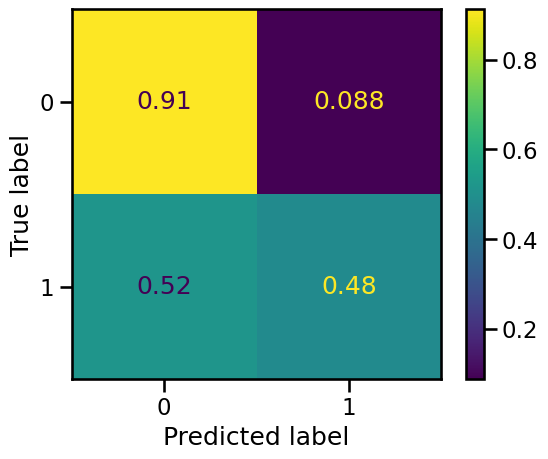

In [ ]:
# Plot the normalized confusion matrix for Linear SVC.
cf_SVC = confusion_matrix(y_test, y_pred, normalize='true')

sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=cf_SVC, display_labels=LinearSVC_model.classes_)
disp.plot()
plt.show()


## KNN Classifier


In [ ]:
# Train the default K-Nearest Neighbors model.
from sklearn.neighbors import KNeighborsClassifier

KNN_model = KNeighborsClassifier()

KNN_model.fit(X_train_scaled, y_train)


y_pred = KNN_model.predict(X_test_scaled)

In [ ]:
# Evaluate the default KNN model.
scores_KNN = get_metrics(y_test, y_pred)
print(scores_KNN)

Confusion Matrix:
[[10888  1787]
 [ 2185  2620]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85     12675
           1       0.59      0.55      0.57      4805

    accuracy                           0.77     17480
   macro avg       0.71      0.70      0.71     17480
weighted avg       0.77      0.77      0.77     17480

{'accuracy': 0.7727688787185355, 'precision': 0.5945087361016564, 'recall': 0.5452653485952134, 'f1_score': 0.5688232739904473}


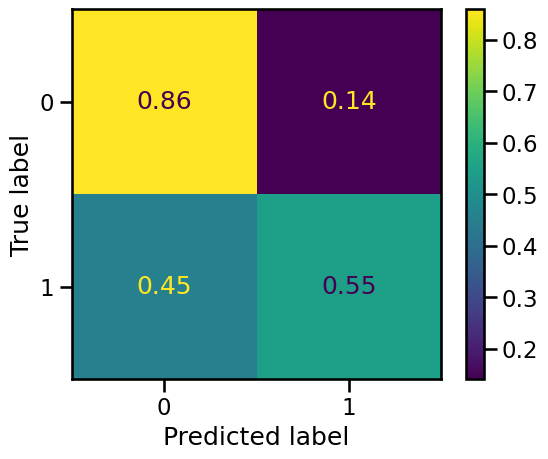

In [ ]:
# Plot the normalized confusion matrix for the default KNN model.
cf_KNN = confusion_matrix(y_test, y_pred, normalize='true')


sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=cf_KNN, display_labels=KNN_model.classes_)
disp.plot()
plt.show()

In [ ]:
# Define a tuned KNN model with distance weighting.
KNN_model_q = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')

In [ ]:
# Train and evaluate the tuned KNN model.
KNN_model_q.fit(X_train_scaled, y_train)

y_pred = KNN_model_q.predict(X_test_scaled)
y_pred_proba = KNN_model_q.predict_proba(X_test_scaled)[:, 1]

scores_KNN_q = get_metrics(y_test, y_pred, y_pred_proba)
print(scores_KNN_q)

Confusion Matrix:
[[10839  1836]
 [ 2080  2725]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85     12675
           1       0.60      0.57      0.58      4805

    accuracy                           0.78     17480
   macro avg       0.72      0.71      0.71     17480
weighted avg       0.77      0.78      0.77     17480

{'accuracy': 0.7759725400457665, 'precision': 0.5974566980925236, 'recall': 0.5671175858480749, 'f1_score': 0.581891949604954, 'roc_auc': 0.8049794038507718}


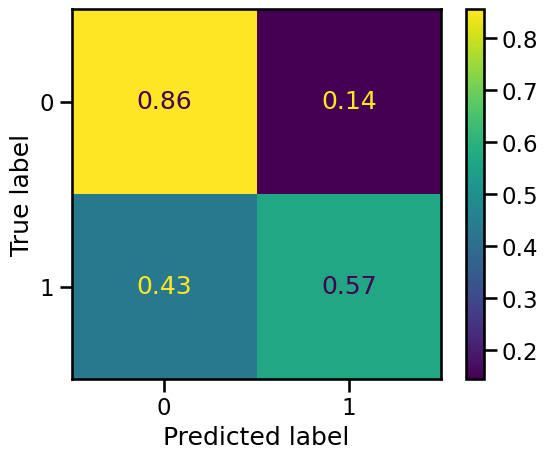

In [ ]:
# Plot the normalized confusion matrix for the tuned KNN model.
cf_KNN_q = confusion_matrix(y_test, y_pred, normalize='true')


sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=cf_KNN_q, display_labels=KNN_model_q.classes_)
disp.plot()
plt.show()

## Decision Tree Classifier


In [ ]:
# Define the Decision Tree classifier.
from sklearn.tree import DecisionTreeClassifier
DT_model = DecisionTreeClassifier(random_state=42)

In [ ]:
# Train and evaluate the Decision Tree model.
DT_model.fit(X_train, y_train)

y_pred = DT_model.predict(X_test)
y_pred_proba = DT_model.predict_proba(X_test)[:, 1]
scores_DT = get_metrics(y_test, y_pred, y_pred_proba)
print(scores_DT)

Confusion Matrix:
[[10713  1962]
 [ 1777  3028]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85     12675
           1       0.61      0.63      0.62      4805

    accuracy                           0.79     17480
   macro avg       0.73      0.74      0.73     17480
weighted avg       0.79      0.79      0.79     17480

{'accuracy': 0.7860983981693364, 'precision': 0.606813627254509, 'recall': 0.6301768990634755, 'f1_score': 0.618274629913221, 'roc_auc': 0.7391088178610791}


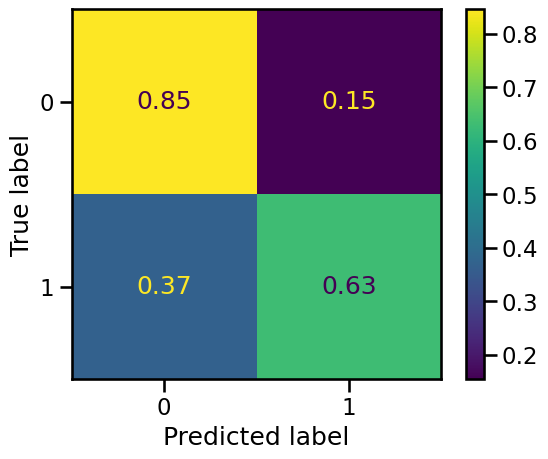

In [ ]:
# Plot the normalized confusion matrix for Decision Tree.
D = confusion_matrix(y_test, y_pred, normalize='true')


sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=D, display_labels=DT_model.classes_)
disp.plot()
plt.show()

## Random Forest Classifier


In [ ]:
# Train the baseline Random Forest model.
from sklearn.ensemble import RandomForestClassifier
RF_model = RandomForestClassifier(max_depth=5, random_state=42, n_jobs=-1)
RF_model.fit(X_train, y_train)
y_pred = RF_model.predict(X_test)

In [ ]:
# Evaluate the baseline Random Forest model.
y_pred_proba = RF_model.predict_proba(X_test)[:, 1]
scores_RF = get_metrics(y_test, y_pred, y_pred_proba)
print(scores_RF)

Confusion Matrix:
[[12675     0]
 [ 4748    57]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      1.00      0.84     12675
           1       1.00      0.01      0.02      4805

    accuracy                           0.73     17480
   macro avg       0.86      0.51      0.43     17480
weighted avg       0.80      0.73      0.62     17480

{'accuracy': 0.72837528604119, 'precision': 1.0, 'recall': 0.01186264308012487, 'f1_score': 0.023447141094199916, 'roc_auc': 0.8246045395677989}


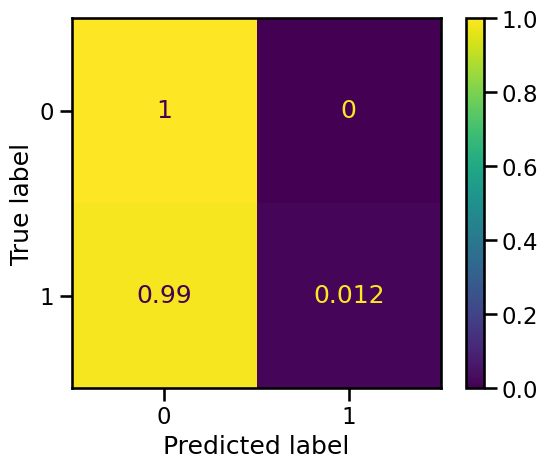

In [ ]:
# Plot the normalized confusion matrix for the baseline Random Forest.
F = confusion_matrix(y_test, y_pred, normalize='true')


sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=F, display_labels=RF_model.classes_)
disp.plot()
plt.show()

In [ ]:
# Import GridSearchCV and define a Random Forest setup for tuning.
from sklearn.model_selection import GridSearchCV

RF_model_param = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

Grid_RF = GridSearchCV(
    estimator=RF_model_param,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

Grid_RF.fit(X_train, y_train)

print("Best params:", Grid_RF.best_params_)
print("Best CV score:", Grid_RF.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Best CV score: 0.7143991357268237


In [ ]:
# Train and evaluate the tuned Random Forest model with chosen hyperparameters.
RF_model_param = RandomForestClassifier(max_depth=None, random_state=42, n_jobs=-1, max_features='sqrt', min_samples_leaf=1, min_samples_split=10, n_estimators=300)
RF_model_param.fit(X_train, y_train)
y_pred = RF_model_param.predict(X_test)
y_pred_proba = RF_model_param.predict_proba(X_test)[:, 1]
scores_RF_param = get_metrics(y_test, y_pred, y_pred_proba)
print(scores_RF_param)

Confusion Matrix:
[[11857   818]
 [ 1973  2832]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.89     12675
           1       0.78      0.59      0.67      4805

    accuracy                           0.84     17480
   macro avg       0.82      0.76      0.78     17480
weighted avg       0.83      0.84      0.83     17480

{'accuracy': 0.8403318077803204, 'precision': 0.7758904109589041, 'recall': 0.5893860561914672, 'f1_score': 0.66989946777055, 'roc_auc': 0.9020022535696913}


## Gradient Boosting Classifier


In [ ]:
# Train and evaluate the Gradient Boosting classifier.
from sklearn.ensemble import GradientBoostingClassifier

GB_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)

GB_model.fit(X_train, y_train)

y_pred = GB_model.predict(X_test)
y_pred_proba = GB_model.predict_proba(X_test)[:, 1]

scores_GB = get_metrics(y_test, y_pred, y_pred_proba)
print(scores_GB)

Confusion Matrix:
[[11707   968]
 [ 2212  2593]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88     12675
           1       0.73      0.54      0.62      4805

    accuracy                           0.82     17480
   macro avg       0.78      0.73      0.75     17480
weighted avg       0.81      0.82      0.81     17480

{'accuracy': 0.8180778032036613, 'precision': 0.7281662454366751, 'recall': 0.5396462018730489, 'f1_score': 0.6198900310781735, 'roc_auc': 0.8743983317837476}


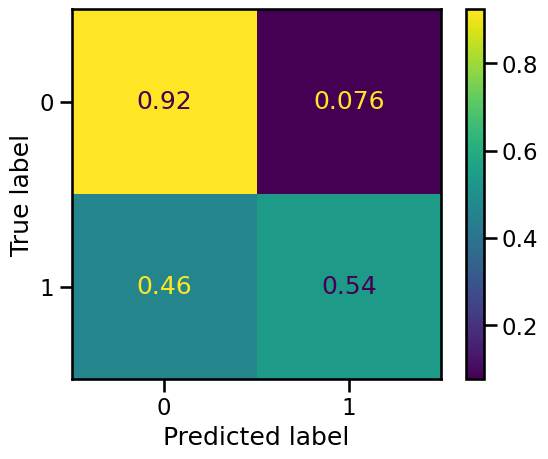

In [ ]:
# Plot the normalized confusion matrix for Gradient Boosting.
G = confusion_matrix(y_test, y_pred, normalize='true')


sns.set_context('talk')
disp = ConfusionMatrixDisplay(confusion_matrix=G, display_labels=GB_model.classes_)
disp.plot()
plt.show()

## Model Comparison and Selection

To evaluate the performance of the models fairly, several metrics were compared, including **accuracy, precision, recall, F1-score, and ROC-AUC**. Because cancellation prediction is an imbalanced classification problem, **F1-score and recall** are especially important when selecting the most useful model.


In [ ]:
# Compare all trained models in one table and visualize their F1 scores.
comparison_df = pd.DataFrame([
    {'Model': 'Logistic Regression', **scores_LR},
    {'Model': 'Linear SVC', **scores_SVC},
    {'Model': 'KNN (default)', **scores_KNN},
    {'Model': 'KNN (weighted)', **scores_KNN_q},
    {'Model': 'Decision Tree', **scores_DT},
    {'Model': 'Random Forest (baseline)', **scores_RF},
    {'Model': 'Random Forest (tuned)', **scores_RF_param},
    {'Model': 'Gradient Boosting', **scores_GB}
])

comparison_df = comparison_df.sort_values(by='f1_score', ascending=False)
display(comparison_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='f1_score', y='Model')
plt.title('Model Comparison by F1 Score')
plt.xlabel('F1 Score')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


,Model,accuracy,precision,recall,f1_score,roc_auc
6,Random Forest param,0.840332,0.775890,0.589386,0.669899,0.902002
7,Gradient Boosting,0.818078,0.728166,0.539646,0.619890,0.874398
4,Decision Tree,0.786098,0.606814,0.630177,0.618275,0.739109
3,KNN,0.775973,0.597457,0.567118,0.581892,0.804979
2,KNN,0.772769,0.594509,0.545265,0.568823,NaN
0,Logistic Regression,0.794108,0.675291,0.483455,0.563493,0.843792
1,Linear SVC,0.793822,0.686086,0.460770,0.551295,NaN
5,Random Forest,0.728375,1.000000,0.011863,0.023447,0.824605


## Final Model Choice and Conclusion

Based on the comparison above, the **tuned Random Forest model** was selected as the best final model for this project because it achieved the **highest F1-score and the strongest overall balance between precision and recall**. This is important because the dataset is imbalanced, so accuracy alone would not be enough to evaluate performance fairly.

### Final selected model
- **Model:** Random Forest (tuned)
- **Why selected:** Best overall classification performance on the test set, especially for identifying canceled bookings while still keeping good precision.

### Key findings
- Features related to **lead time, deposit type, market segment, ADR, and room/reservation characteristics** played an important role in predicting cancellations.
- The baseline Random Forest with shallow depth underperformed badly on recall, which shows that hyperparameter tuning was necessary.
- Simpler linear models gave reasonable results, but tree-based models captured the complex patterns in the data more effectively.

### Final conclusion
This project demonstrates that supervised machine learning can be used successfully to predict hotel booking cancellations. After comparing multiple classification models, the tuned Random Forest provided the best balance of performance and practical usefulness.

These results suggest that hotels can use booking details and customer behavior variables to identify reservations with a higher cancellation risk. This kind of prediction can support better planning, pricing, and resource allocation.


## Feature Importance of the Best Model

Feature importance was used to interpret the tuned Random Forest model and identify which variables contributed most to prediction. This step is valuable because it connects model performance to meaningful business insight.


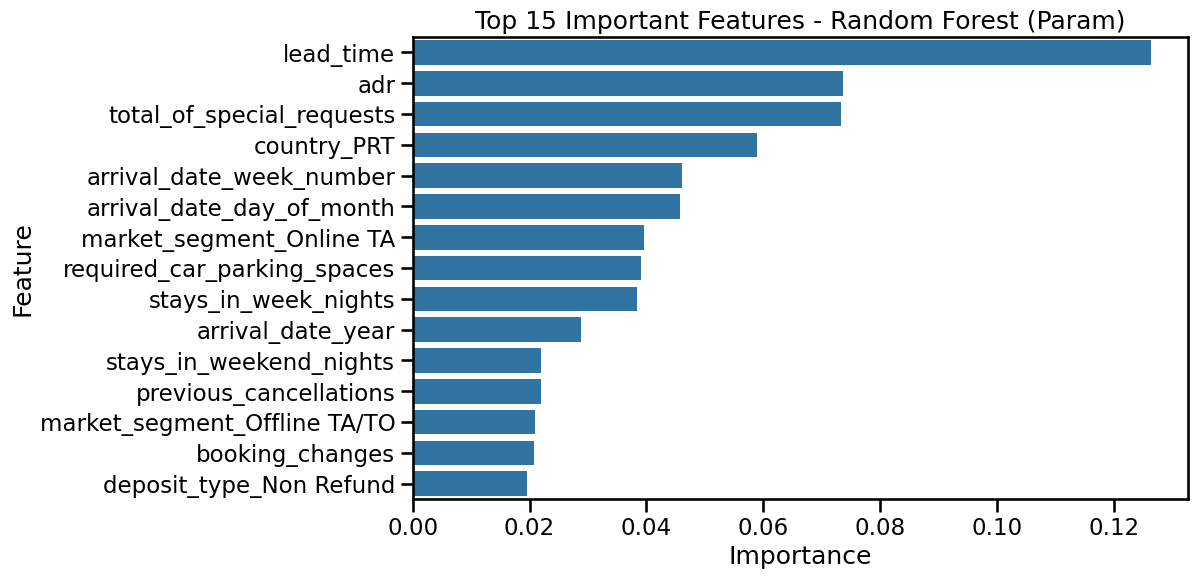

In [ ]:
# Plot the top 15 most important features from the tuned Random Forest model.
feature_importance = pd.Series(RF_model_param.feature_importances_, index=X_train.columns)
top_features = feature_importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title('Top 15 Important Features - Random Forest (Param)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Submission Note

This notebook documents the full workflow required for the final project:
- dataset understanding
- preprocessing and cleaning
- exploratory data analysis
- model training and evaluation
- model comparison
- final model selection and conclusion

The notebook is structured so it can be exported as PDF for submission.
